In [10]:
import importlib
import sftools
import sftools.postprocess as pp
import sftools.plotting    as pl
import sftools.validation  as val
importlib.reload(sftools.validation)
importlib.reload(sftools.plotting)
import sftools.validation  as val
import sftools.plotting as pl



## Open data

In [7]:
H = "hindcast/model-runs/Canary_12/20251225/hcast/CROCO_FILES/croco_his.nc"
ds = pp.open_history(H, Yorig=1993)

#### Parameters

In [8]:
depth = 1000
lon0, lat0, lon1, lat1 = -21, -16, 21, 21
isobaths = [100, 200, 500, 1000, 2000]


## Horizontal section

### Salinity

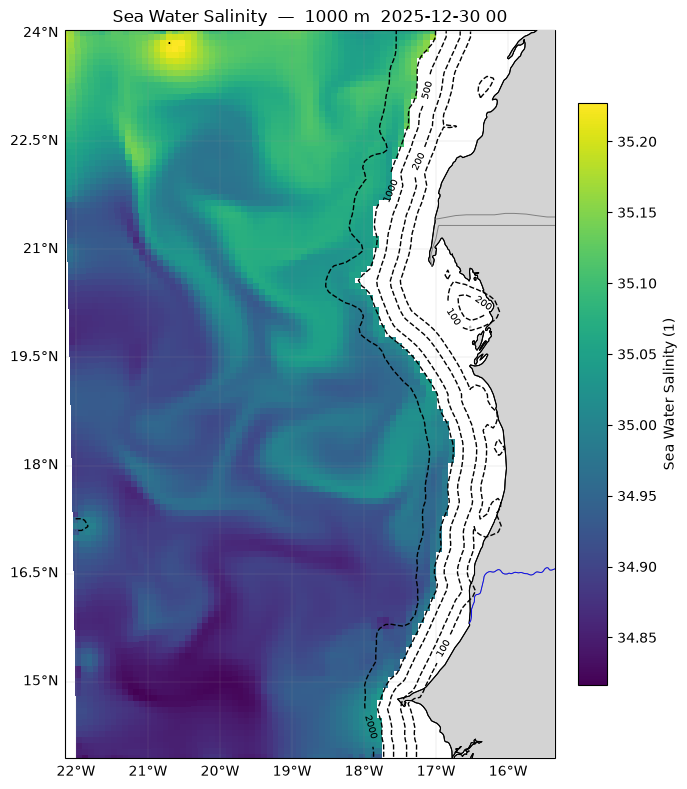

In [11]:
%matplotlib inline

fig = pl.plot(pp.field(ds, "salt", depth_m=depth),ds=ds, isobaths=isobaths)   # no out= -> returns the figure


### Temperature

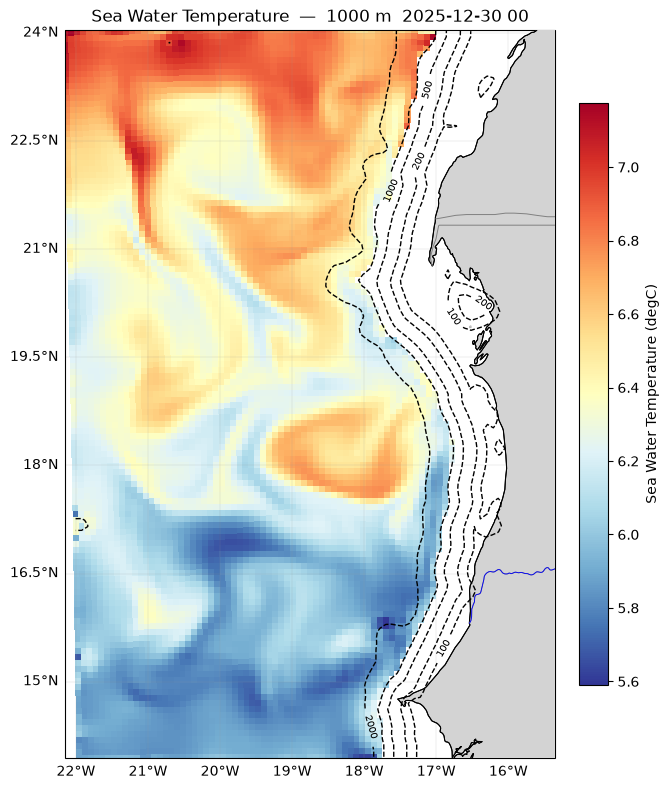

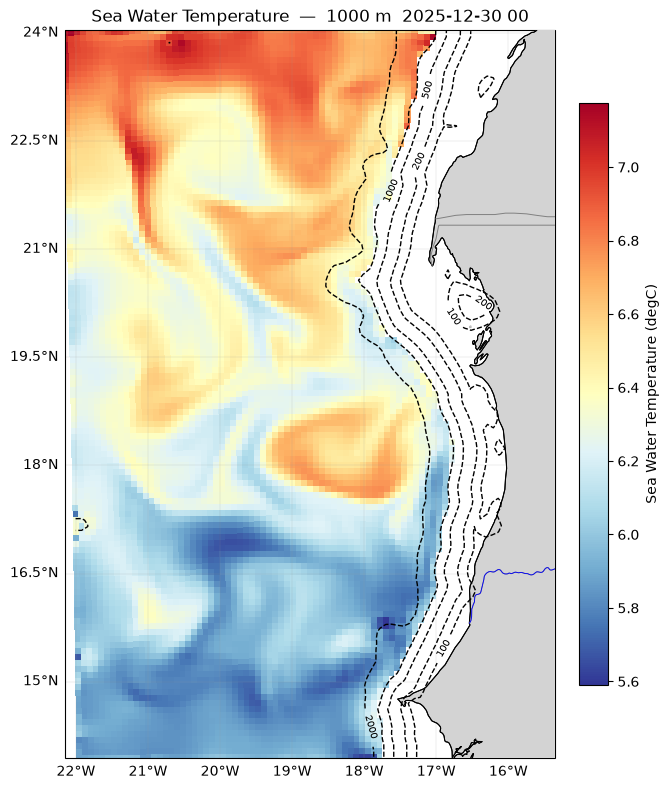

In [9]:
fig = pl.plot(pp.field(ds, "temp", depth_m=depth),ds=ds, isobaths=isobaths)   # no out= -> returns the figure
fig

### Curent & Speed at depth

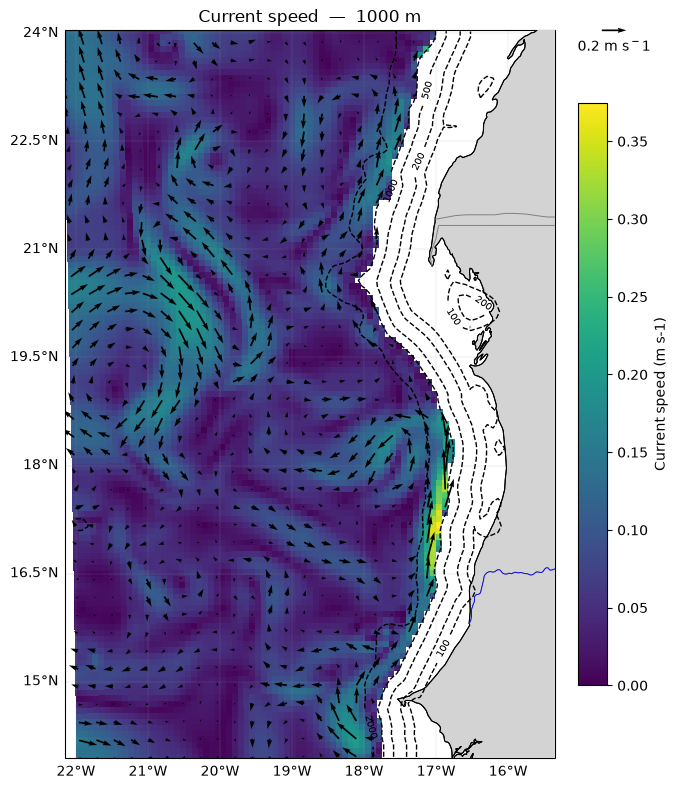

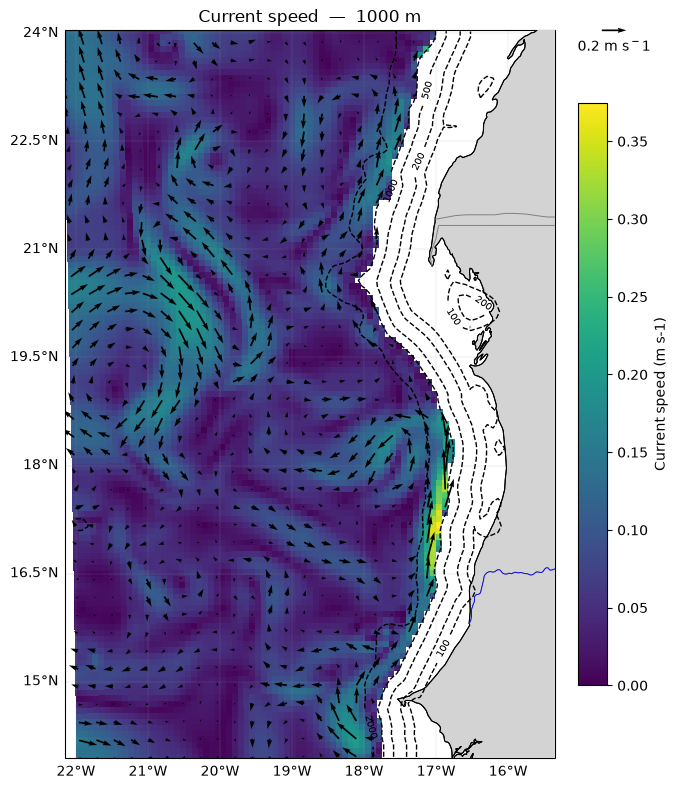

In [12]:
# u, v = pp.surface_uv(ds,tindex=-1); # u,v at surface
# u, v = pp.rotate_uv(ds, u, v) #rotate to east/north for surface currents
u, v = u, v = pp.uv_at_depth(ds, depth_m=depth, tindex=-1, rotate=True)  # u,v at depth; 
fig=pl.plot(pp.speed_map(ds,depth_m=depth),ds=ds, uv=(u, v),isobaths=isobaths,uv_scale=4, uv_skip=3, uv_ref=0.2)   # saves to file, returns the filename
fig

### Vorticity

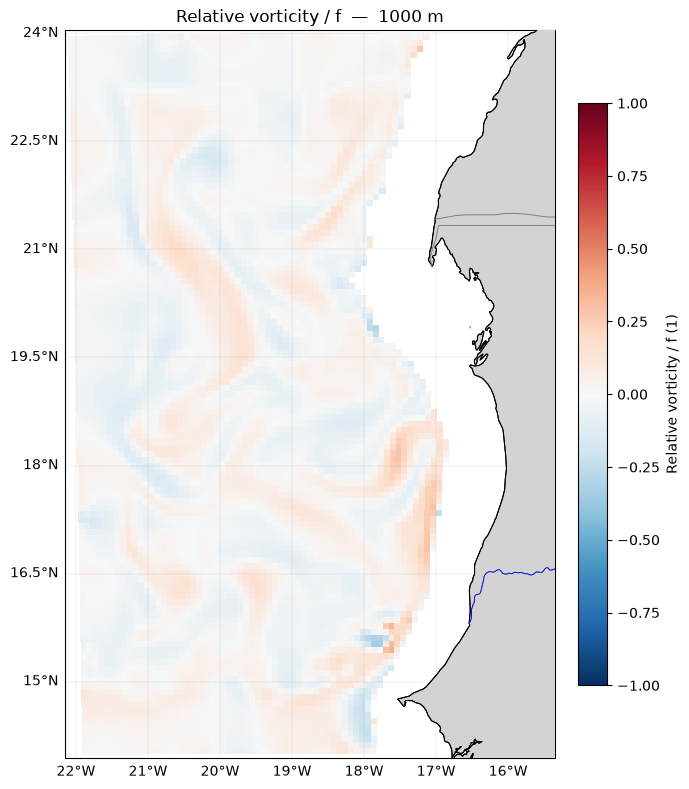

In [18]:
fig=pl.plot(pp.vorticity(ds,depth_m=depth, normalized=True)) 
fig

### Combined eddy view: shaded base field + vorticity contours or current vectors

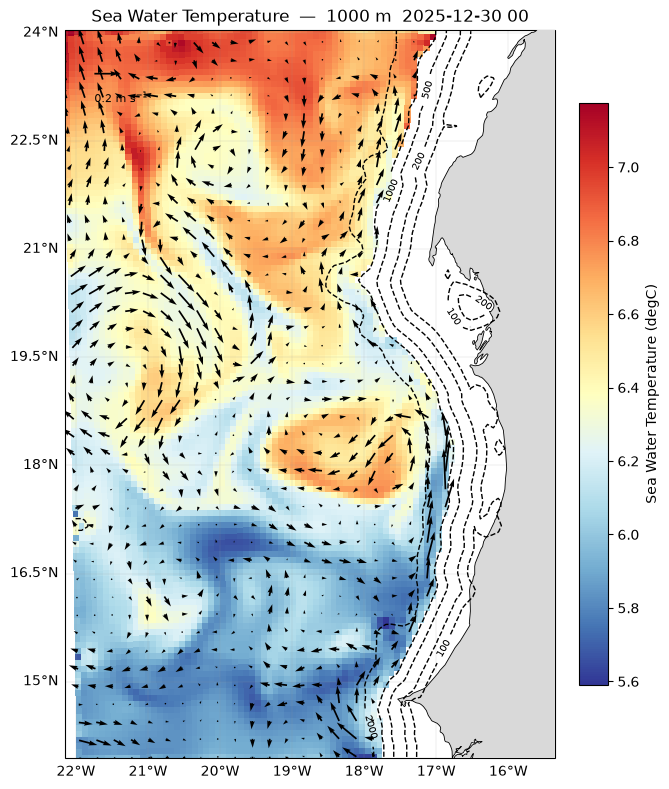

In [147]:
# overlay : ('vort', vort_da)  -> vorticity contours (from vort/f)
#               ('uv', (u, v))     -> current vectors
fig = pl.plot_eddy(pp.field(ds, "temp", depth_m=depth),ds=ds, isobaths=isobaths,overlay= ('uv', (u, v)),uv_scale=4, uv_skip=3, uv_ref=0.2)   # no out= -> returns the figure
fig

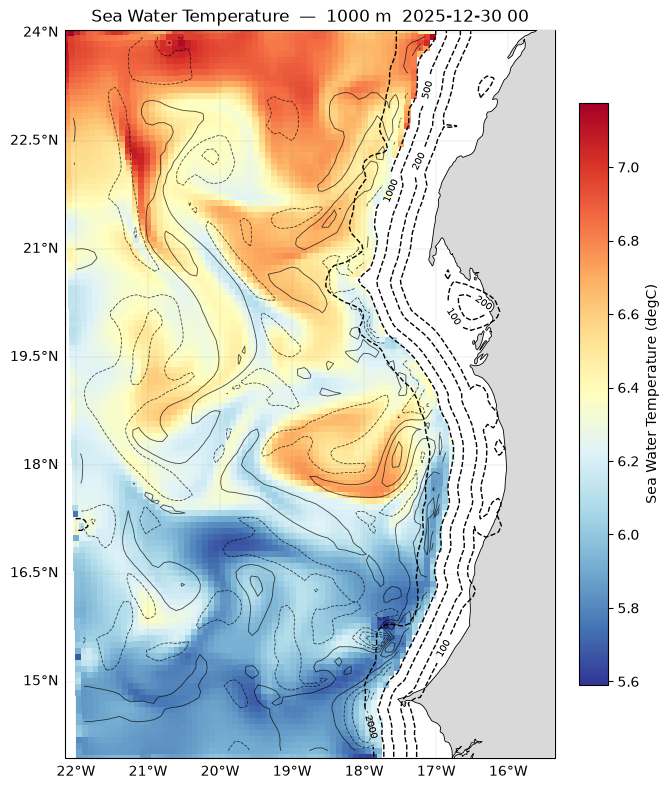

In [94]:
# overlay : ('vort', vort_da)  -> vorticity contours (from vort/f)
#               ('uv', (u, v))     -> current vectors
vort_da = pp.vorticity(ds,depth_m=depth, normalized=True)
fig = pl.plot_eddy(pp.field(ds, "temp", depth_m=depth),ds=ds, isobaths=isobaths,overlay= ('vort', vort_da))   # no out= -> returns the figure
fig

# ________________________________________________________________________________________________________________________________________

## Vertical section

### salinity

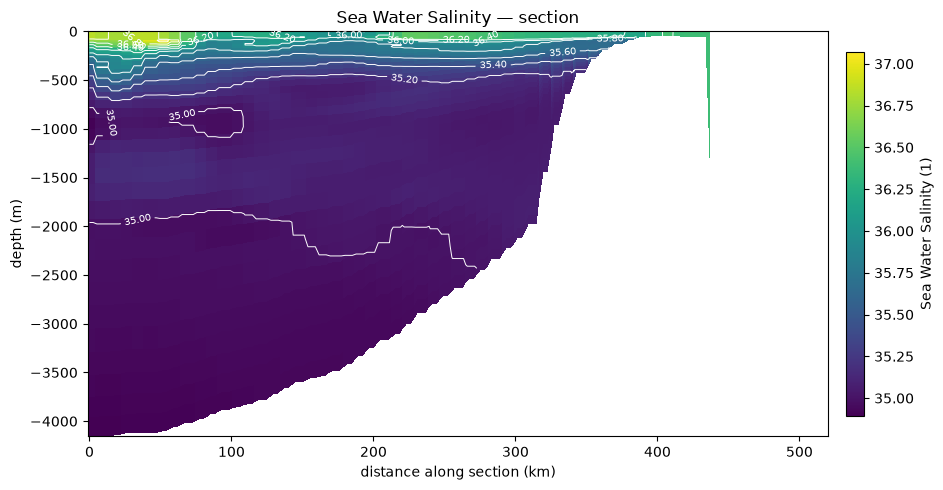

In [14]:
fig=pl.plot(pp.section(ds, "salt",  lon0, lon1, lat0, lat1),contour_colors="white", levels=10)   # no out= -> returns the figure


### temperature

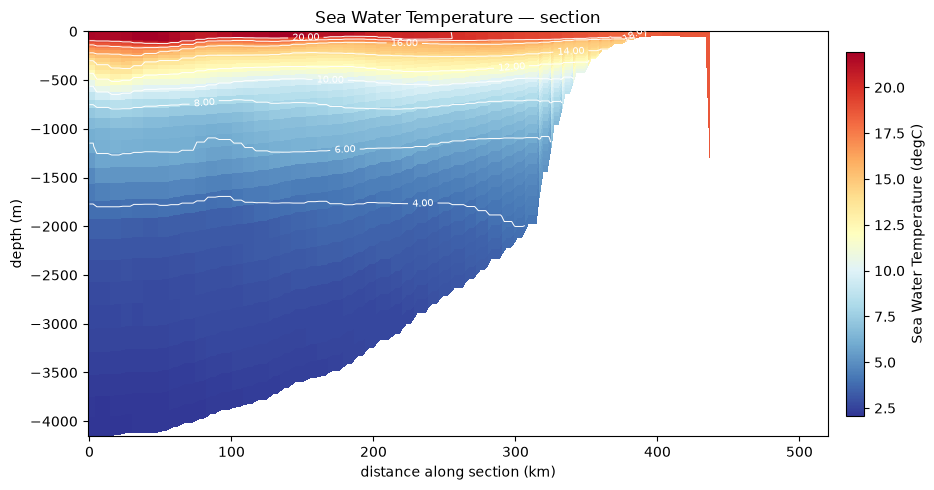

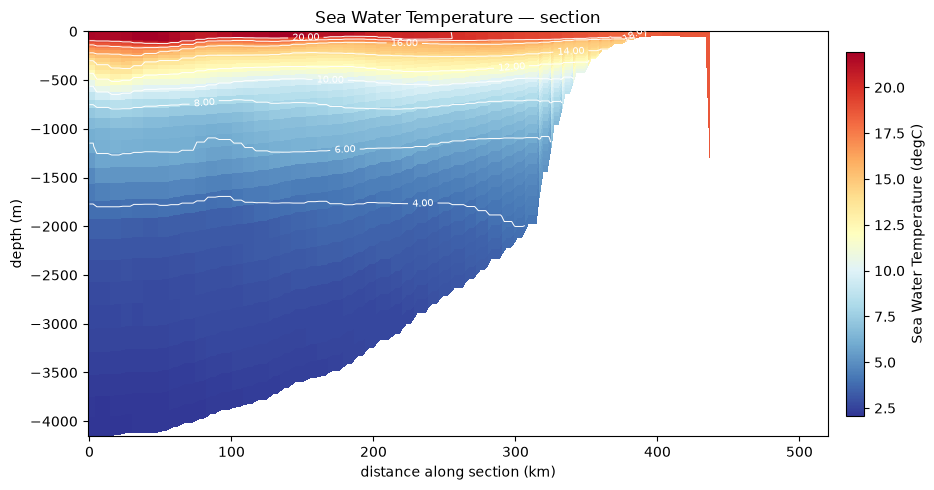

In [13]:
fig=pl.plot(pp.section(ds, "temp",  lon0, lon1, lat0, lat1),contour_colors="white", levels=10)   # no out= -> returns the figure
fig

### speed

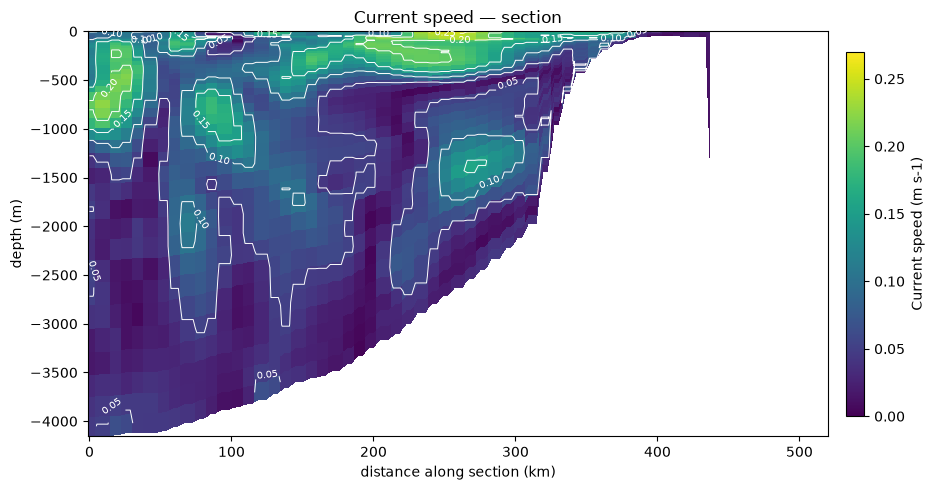

In [119]:
fig=pl.plot(pp.section(ds, "speed",  lon0, lon1, lat0, lat1),contour_colors="white", levels=5)   # no out= -> returns the figure
fig

# ________________________________________________________________________________________________________________________________________

## Vertcal Profil

###  salinity

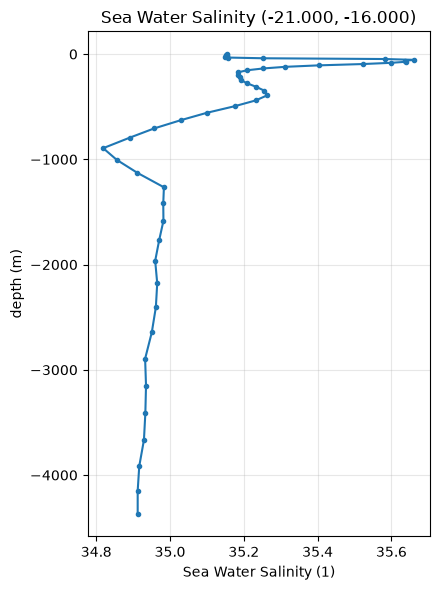

In [164]:
fig=pl.plot(pp.profile(ds, "salt",  lon0, lat0))

###  temperature

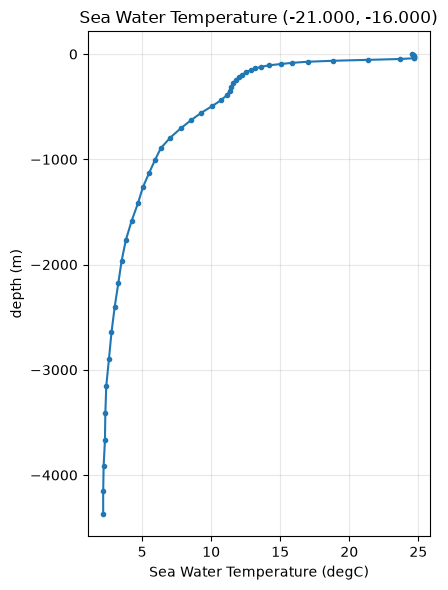

In [121]:
fig=pl.plot(pp.profile(ds, "temp",  lon0, lat0))
fig

###  speed

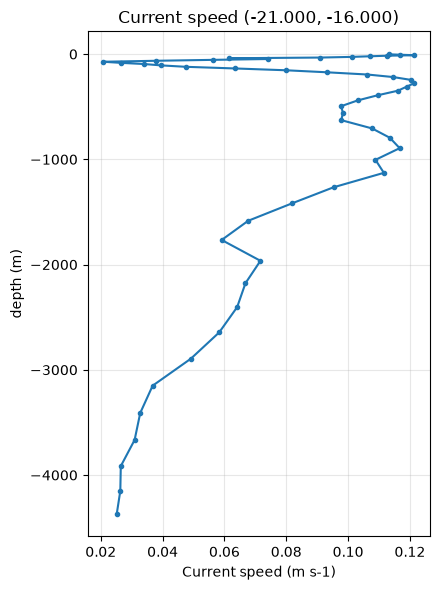

In [122]:
fig=pl.plot(pp.profile(ds, "speed",  lon0, lat0))
fig

## Hovmöller diagrams

### salinity

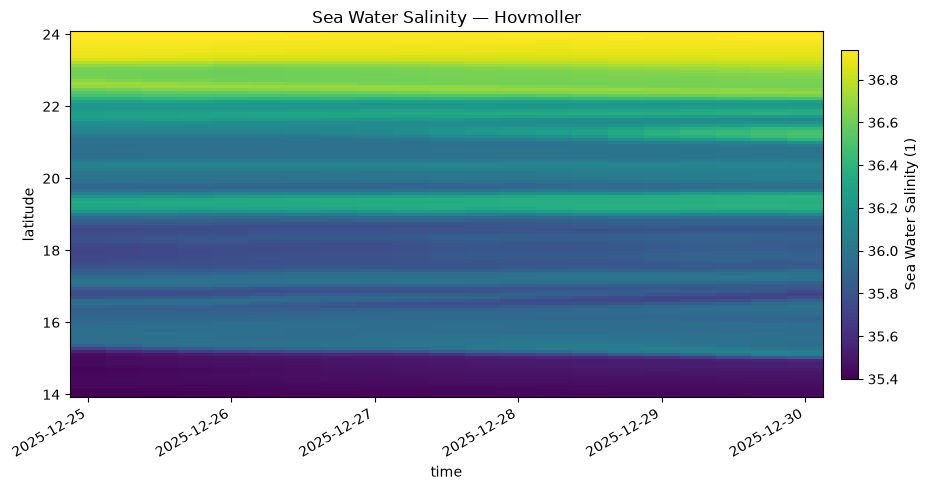

In [141]:
fig = pl.plot(pp.hovmoller(ds, "salt", "time_lat", lon0=-19))
fig

### temperature

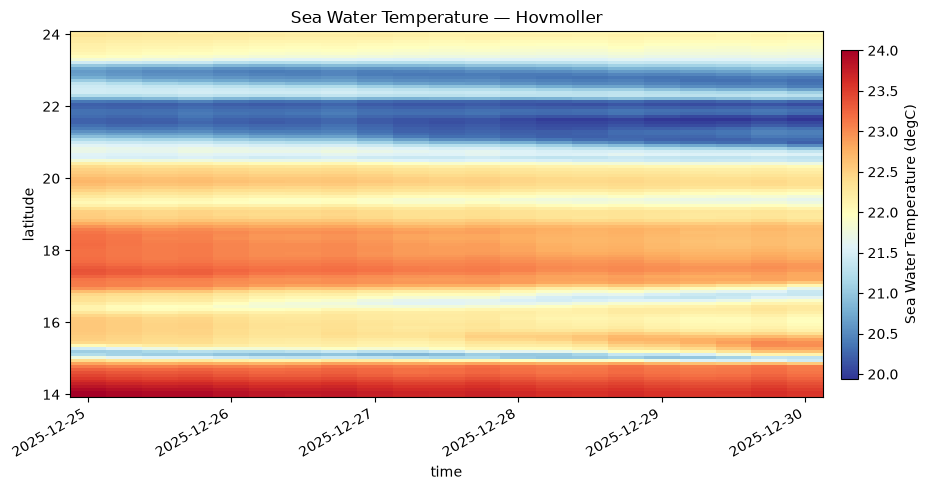

In [142]:
fig = pl.plot(pp.hovmoller(ds, "temp", "time_lat", lon0=-19))
fig

## Time series

#### surface SST over time

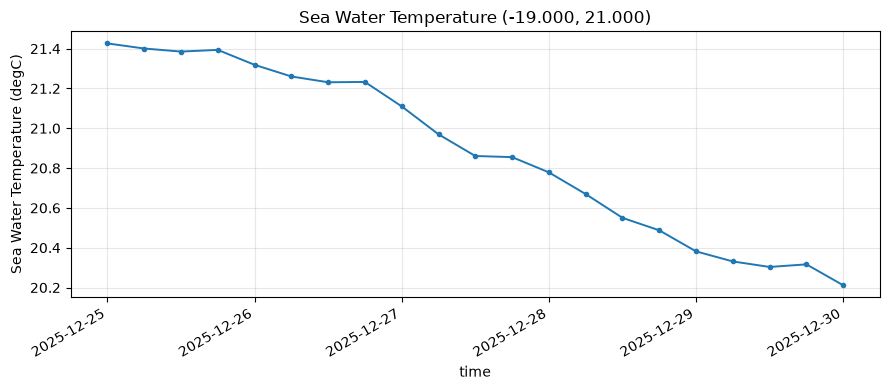

In [136]:
fig=pl.plot(pp.timeseries(ds, "temp",   lon0=-19, lat0=21))
fig

### temperature at depth over time

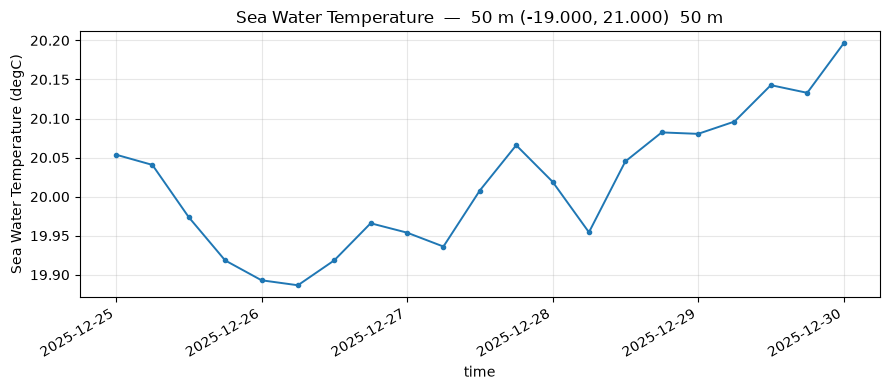

In [137]:
fig=pl.plot(pp.timeseries(ds, "temp", lon0=-19, lat0=21,depth_m=50))
fig

### salinity at depth over time

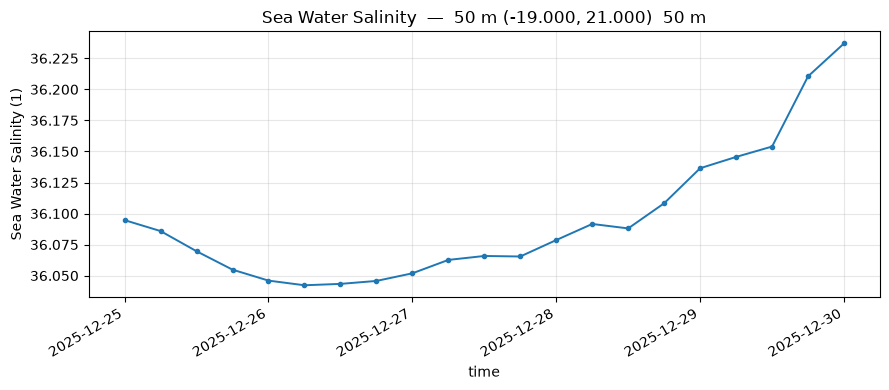

In [140]:
fig=pl.plot(pp.timeseries(ds, "salt", lon0=-19, lat0=21,depth_m=50))
fig

#### SSH over time

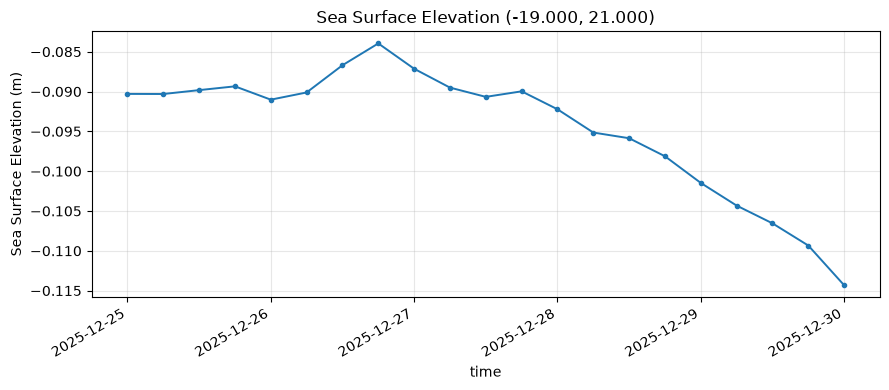

In [ ]:
fig = pl.plot(pp.timeseries(ds, "zeta",  lon0=-19, lat0=21))
fig

#### Speed at depth over time

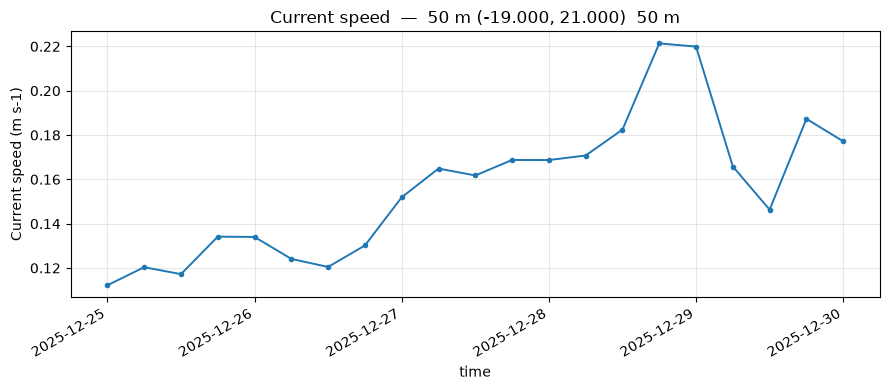

In [11]:
fig = pl.plot(pp.timeseries(ds, "speed",  lon0=-19, lat0=21, depth_m=50))


# _________________________________________________________________________________________________________________________________________________________________________

## Validation

In [ ]:

# validate the forecast against Mercator
F    = "forecast/model-runs/Canary_12/20260711/fcst/CROCO_FILES/croco_his.nc"
MERC = "forecast/scratch/Canary_12/downloaded_data/MERCATOR/MERCATOR_20260711_00.nc"

SST  CROCO vs parent:
  [SST]  n=8390  bias=-0.050  RMSE=0.424  cRMSE=0.421  corr=0.980


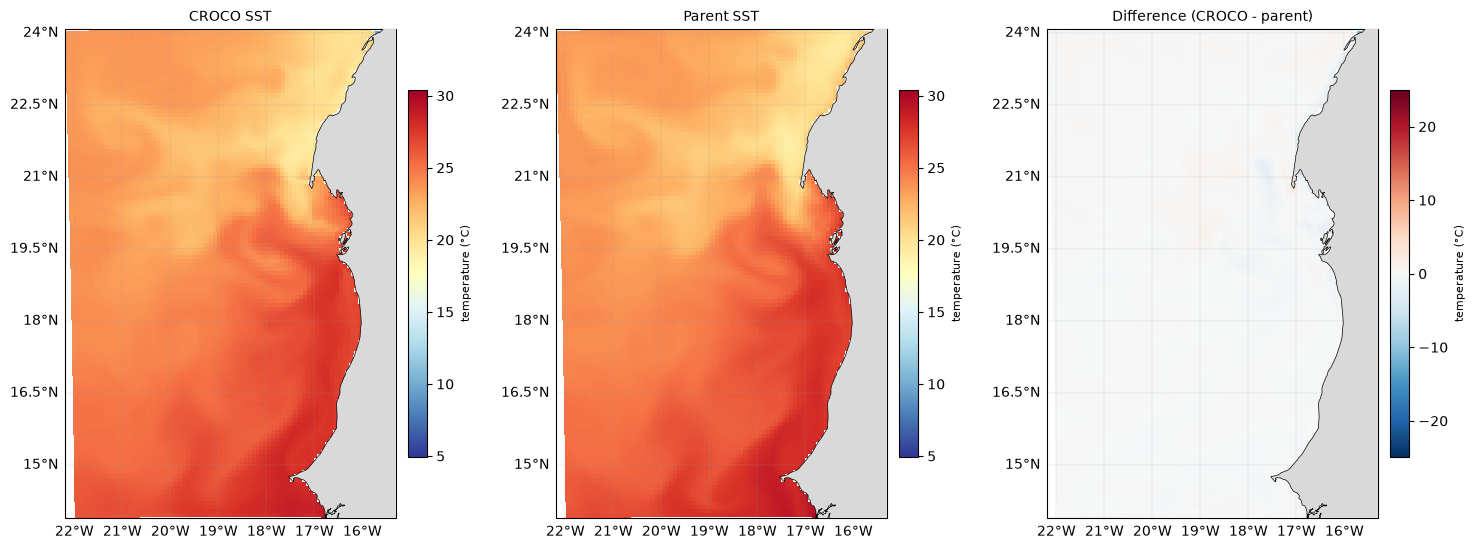

In [ ]:
res,s=val.compare_sst(F, MERC, date="2026-07-11", Yorig=2000)


In [ ]:
%